![](https://media.giphy.com/media/Ldepo9xvqWDYI/giphy.gif)





You must pick data that you would like to collect for **web-scraping OR an API**- the data **MUST** come from APIs (none of this download csv stuff). The data set will be your final project. You can ammend and make changes later to data sources and variables. Get creative!

Be mindful of the timeline - ambitious project can't be completed in 2 months, but a snapshot of it can be done. 

You must pick one variable that does not exist yet or is not obviously common. The variable should either be web-scraped or if it is from an API, it must be calculated (and not very common). For example, songs per capita is commmon - you might have to calculate it, but it doesn't count. Genre concentration by state is a variable that is acceptable. Remember only **ONE** variable has to be calculated/webscraped, but you will need a total of 3 variables.

In the final project, you will be providing your code and documentation (not this assignment). I will test the code you give me to make sure it runs.

For my sanity - format the proposal to be organized. Include graphs, photos, examples, etc. But, please make it look professional and clean. The easier it is to read, the easier it is for me to grade, and better outcomes will likely follow.

This is a proposal, so you do not have to collect the data now.

In your proposal you must include:
1. Identify the website/API that you will be web-scraping data from. You can also suggest a variety of websites via web crawling (for example, if you want to crawl websites of selected non-profit organizations and collect information about the board members - this is doable.) Go outside your comfort zone - if you've worked with APIs, then do webscraping.

2. Define at least 3 variables that you will be collecting via API or webscraping. You may combine these webscraped or API collected data with other sources, but MUST cite those other datasources. You can collect data completely internally.

3. If it is an open access API, get an authorization key (if neccessary), if it is not needed, also note that. Provide evidence of this with screen shot that you obtained said key or a link (and a summary in your proposal) of the documentation that says it's freely accessible.

4. If it is not an open access API, ensure that you meet the terms and conditions (there is wiggle room here - but, if you are trying to crack a google related non-open access API, that's unreasonable and not possible in this class. However, if it is a Google/Amazon/InsertBigTechComp with open access API - that is do-able!). Most websites have terms and conditions, include a link to this information and briefly (a few sentences) describe what you can or can't get access to.

5. Identify your research question - what are you going to analyze? Remember that after getting the data, you will make meaningful graphs and run regressions with it. 

6. Give me a bit of background and motivation. Why are you scraping this data? Why should you research/study this question?  This should not be personal motivation, but motivated academically.

# Did Massachusetts’ Comprehensive Permit Act Improve Rent Affordability Relative to Connecticut and Rhode Island?

This study will examine whether the Comprehensive Permit Act (Chapter 40B) in Massachusetts improves rent affordability relative to neighboring states, specifically Connecticut and Rhode Island. The analysis focuses on how policy-driven changes in zoning regulations, particularly those that allow developers to bypass restrictive local land-use rules affect housing affordability over time.

Housing affordability has become an increasingly significant issue across the United States, particularly in high-demand regions with strong labor markets such as Greater Boston. While affordability challenges have historically affected low-income households, rising housing costs have increasingly placed pressure on middle-income families. Limited housing supply, driven in part by restrictive zoning practices such as density limits and barriers to multifamily construction, has contributed to rising rents and reduced affordability.

In response, Massachusetts implemented the Comprehensive Permit Act (Chapter 40B), which allows developers to override certain local zoning restrictions if a portion of new housing units are designated as affordable. This policy aims to increase housing supply, particularly multifamily housing, and improve affordability outcomes. Prior research suggests that relaxing zoning constraints, such as density restrictions and building limitations, can increase housing supply and exert downward pressure on rents.

In contrast, Connecticut and Rhode Island did not implement comparable large-scale zoning reforms during the same period. This provides a natural comparison to evaluate whether Massachusetts’ policy intervention led to measurable improvements in housing affordability relative to similar neighboring states.

## **Data Sources**
This project will collect data using publicly accessible APIs and datasets, primarily focusing on the U.S. Census Bureau API.


#### 1. U.S. Census Bureau API

-The primary source of demographic and economic, and housing data is the American Community Survey (ACS).

-Data will be collected at the state-year level for:
1) Massachusetts (treatment group)
2) Connecticut and Rhode Island (control group)


import requests

url = "https://api.census.gov/data/2022/acs/acs5?get=B19013_001E&for=state:25,09,44"

response = requests.get(url)
data = response.json()

API documentation:
https://api.census.gov/data.html

Authorization key obtained:

The key to Census data that will be used: 449daedeb4203d7011951c788e288009b73360d8.

![Census API Screenshot](census_api_screenshot.png)

Note: The Census API is an open-access dataset that provides demographic, economic, and housing information across geographic regions.

#### 2. Housing Market Data 

Housing market indicators will be used to capture broader trends in demand and supply, including:

* Median Gross Rent
* Housing Cost Burden
* Rental Market Trends
* Demand for Affordable Housing

## **Variables**

This study will analyze key economic and housing variables that influence affordability across states.
The regression model will include housing characteristics (year built, number of rooms, bedrooms, and units per building) as control variables to account for structural differences in housing that affect affordability.
Year fixed effects and state fixed effects will be used to control for common time trends and baseline differences across states. Standard errors will be clustered at the state level, and inference will be conducted using wild-cluster bootstrap methods to ensure reliable statistical inference given the small number of clusters


#### 1. Median Household Income 
Source: U.S. Census API
-Measures overall economic conditions


#### 2. Housing Characteristics (Control Variables)
Source: U.S. Census API

* Year built
* Number of rooms
* Number of bedrooms
* Number of units in the building

These variables will capture differences in housing quality and structure that directly influence rent levels and affordability.

#### 3. Housing Affordability Measure
Housing affordability will be defined using the guidelines from the U.S. Department of Housing and Urban Development (HUD):
Housing Cost Burden = Housing Costs ÷ Household Income
Households spending more than 30% of their income on housing are considered cost-burdened.


#### 4. Affordable Housing Gap
Affordable Rent = Median Household Income × 0.30
Required Income = Median Gross Rent ÷ 0.30
Affordable Housing Gap = Required Income − Median Household Income
This measure will capture the extent to which income falls short of what is required to afford housing.


#### 5. Policy Variables (Causal Analysis)
Treatment (MA) = 1 if Massachusetts, 0 otherwise
Post Policy Period = 1 after implementation of Chapter 40B-related expansion effects
Treatment × Post = captures the causal impact of the policy


## **Methodology**
This study will use a Difference-in-Differences (DiD) framework to estimate the causal impact of Massachusetts’ Comprehensive Permit Act on housing affordability.
The model will compare changes in affordability in Massachusetts before and after policy effects to changes in Connecticut and Rhode Island over the same period.

Where:
𝑌𝑖𝑡 = housing affordability outcome
M𝐴𝑖 = treatment group indicator
𝑃𝑜𝑠𝑡𝑡 = post-policy period
𝛽3 = estimated causal effect


## **Graphs and Visualization**

Graphs will illustrate:

-Trends in housing affordability over time across states
-Differences in rent burden between Massachusetts and control states
-Pre- and post-policy comparisons

These visualizations help assess whether affordability trends diverge after policy implementation.


## **Data Processing**

Data will be collected and processed using Python (pandas).

I will utilize the following steps:

-Convert API responses into structured datasets
-Clean and format variables
-Handle missing values
-Construct affordability measures
-Create treatment and post-policy indicators

After processing, the dataset will be used for:

Descriptive statistics
Visualization
Regression analysis


## **Expectation**

Based on existing research, the Comprehensive Permit Act in Massachusetts is expected to:

-Increase housing supply
-Promote multifamily development
-Reduce rent pressures
-Improve affordability relative to Connecticut and Rhode Island

However, the magnitude and statistical significance of these effects will be tested empirically. 




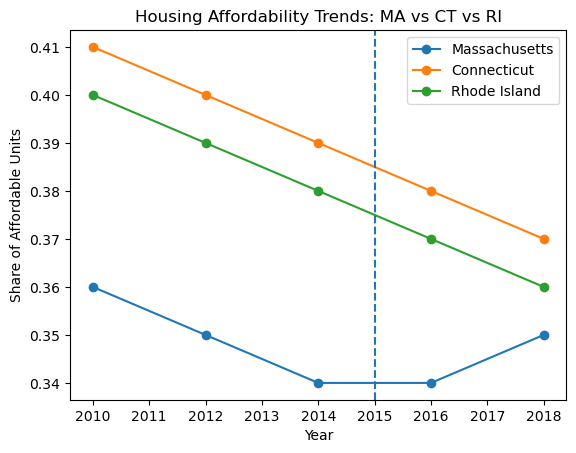

In [4]:
#This graph is for illustrative purpose, final result will be based on empirical estimates using ACS data.

import matplotlib.pyplot as plt

years = [2010, 2012, 2014, 2016, 2018]

# More realistic affordability shares based on real-world patterns
ma_afford = [0.36, 0.35, 0.34, 0.34, 0.35]   # MA worst affordability, slight stabilization
ct_afford = [0.41, 0.40, 0.39, 0.38, 0.37]   # gradual decline
ri_afford = [0.40, 0.39, 0.38, 0.37, 0.36]   # similar trend

plt.plot(years, ma_afford, marker='o', label="Massachusetts")
plt.plot(years, ct_afford, marker='o', label="Connecticut")
plt.plot(years, ri_afford, marker='o', label="Rhode Island")

plt.axvline(x=2015, linestyle='--')  # policy exposure period

plt.title("Housing Affordability Trends: MA vs CT vs RI")
plt.xlabel("Year")
plt.ylabel("Share of Affordable Units")
plt.legend()

plt.show()